# Before your start:

    Read the README.md file
    Comment as much as you can and use the resources (README.md file)
    Happy learning!

In this exercise, we  will generate random numbers from the continuous disributions we learned in the lesson. There are two ways to generate random numbers:

1. Using the numpy library 
1. using the Scipy library 

Use either or both of the lbraries in this exercise.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns

## Uniform Distribution

To generate uniform random numbers between any two given values using scipy, we can either use the following code or the code that we have
discussed in class:

**Your task:**

1. Based on the code above, write a function that generates uniformly distributed random numbers. There are several requirements for your function:
    * It should accept 3 parameters: 
        * `bottom` - the lower boundary of the generated numbers
        * `ceiling` - the upper boundary of the generated numbers
        * `count` - how many numbers to generate
    * It should return an array of uniformly distributed random numbers

1. Call your function with 2 sets of params below:
    * bottom=10, ceiling=15, count=100
    * bottom=10, ceiling=60, count=1,000

1. Plot the uniform distributions generated above using histograms, where x axis is the value and y axis is the count. Let the histogram's number of bins be 10.

Your output should look like below:

![uniform distribution](ud.png)

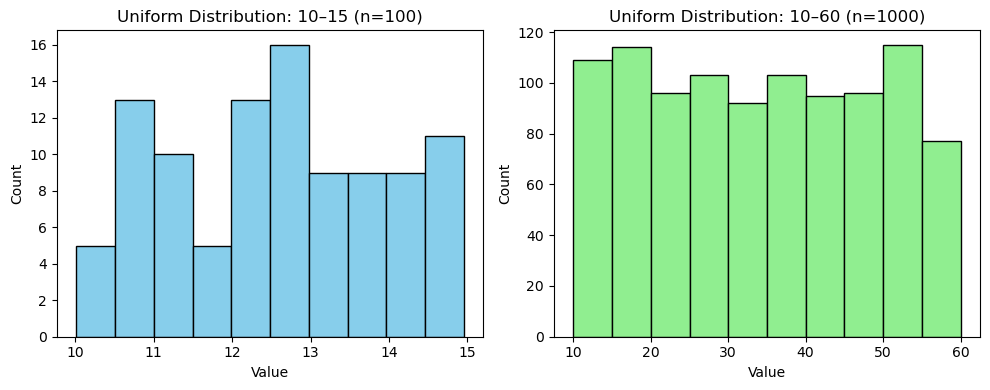

In [3]:
# your code here

# --- Import required libraries ---
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- Function definition ---
def generate_uniform_numbers(bottom, ceiling, count):
    """
    Generate uniformly distributed random numbers.

    Parameters:
        bottom (float): Lower boundary of the range
        ceiling (float): Upper boundary of the range
        count (int): Number of random values to generate

    Returns:
        np.ndarray: Array of uniformly distributed random numbers
    """
    # Create a uniform distribution between bottom and ceiling
    uniform_dist = stats.uniform(loc=bottom, scale=ceiling - bottom)
    
    # Generate 'count' random numbers
    random_values = uniform_dist.rvs(size=count)
    
    return random_values


# --- Call the function with the first set of parameters ---
data_1 = generate_uniform_numbers(bottom=10, ceiling=15, count=100)

# --- Call the function with the second set of parameters ---
data_2 = generate_uniform_numbers(bottom=10, ceiling=60, count=1000)


# --- Plot histograms for both distributions ---
plt.figure(figsize=(10,4))

# First plot
plt.subplot(1, 2, 1)
plt.hist(data_1, bins=10, color='skyblue', edgecolor='black')
plt.title('Uniform Distribution: 10–15 (n=100)')
plt.xlabel('Value')
plt.ylabel('Count')

# Second plot
plt.subplot(1, 2, 2)
plt.hist(data_2, bins=10, color='lightgreen', edgecolor='black')
plt.title('Uniform Distribution: 10–60 (n=1000)')
plt.xlabel('Value')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


How are the two distributions different?

Both follow a Uniform Distribution — meaning every value in their range has equal probability — but:

> - The width of the interval affects the scale of the x-axis (how spread out the values are).

> - The number of generated samples affects the smoothness of the histogram (how close it looks to the ideal flat line).

If we kept increasing count, both histograms would flatten further and resemble perfect rectangles

In [6]:
# your answer below

## Normal Distribution

1. In the same way in the Uniform Distribution challenge, write a function that generates normally distributed random numbers.
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 1
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 50
2. Plot the distributions of the data generated.

Expected output:

![normal distribution](nd.png)

In [7]:
from scipy.stats import norm 

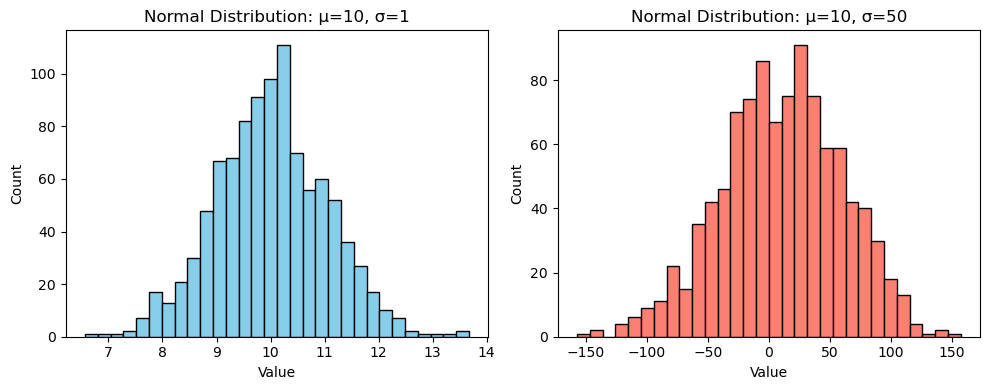

In [16]:
# --- Import required libraries ---
from scipy import stats       # Import the 'stats' module from SciPy, which contains statistical distributions and functions
import matplotlib.pyplot as plt  # Import Matplotlib for plotting histograms


# --- Function definition ---
def generate_normal_numbers(mean, std, count):
    """
    Generate normally distributed random numbers.

    Parameters:
        mean (float): The mean (μ) of the distribution (center point)
        std (float): The standard deviation (σ), which controls spread
        count (int): Number of random values to generate

    Returns:
        np.ndarray: Array of normally distributed random numbers
    """

    # Create a normal distribution object with given mean and standard deviation
    # loc = mean (μ)  → defines the center of the distribution
    # scale = std (σ) → defines the width or spread of the bell curve
    normal_dist = stats.norm(loc=mean, scale=std)

    # Generate 'count' random values that follow this normal distribution
    # rvs() stands for "random variates" — it samples random points
    random_values = normal_dist.rvs(size=count)

    # Return the generated random values to the main program
    return random_values


# --- Generate datasets ---
# Create two datasets, both with the same mean (μ=10) but different standard deviations (σ)
data_1 = generate_normal_numbers(mean=10, std=1, count=1000)    # Narrow bell curve → most values close to 10
data_2 = generate_normal_numbers(mean=10, std=50, count=1000)   # Wide bell curve → values spread far from 10


# --- Plot both distributions ---
plt.figure(figsize=(10,4))       # Create a figure (canvas) 10 inches wide by 4 inches tall


# First plot: Normal Distribution with σ = 1
plt.subplot(1, 2, 1)             # Divide the figure into 1 row × 2 columns → select position 1
plt.hist(data_1, bins=30, color='skyblue', edgecolor='black')  # Plot histogram with 30 bins and blue color
plt.title('Normal Distribution: μ=10, σ=1')  # Title shows the parameters used
plt.xlabel('Value')              # Label for x-axis (horizontal)
plt.ylabel('Count')              # Label for y-axis (vertical, frequency of values)


# Second plot: Normal Distribution with σ = 50
plt.subplot(1, 2, 2)             # Same grid → now select position 2 (right-hand plot)
plt.hist(data_2, bins=30, color='salmon', edgecolor='black')   # Plot histogram of the wider spread data
plt.title('Normal Distribution: μ=10, σ=50')  # Title showing mean and standard deviation
plt.xlabel('Value')              # Label x-axis again
plt.ylabel('Count')              # Label y-axis again


# Final display settings
plt.tight_layout()               # Adjust spacing between subplots so titles/labels don’t overlap
plt.show()                       # Render the plots to the screen


How are the two distributions different?

Both distributions are normal and centered at μ = 10, but the standard deviation changes how tightly or loosely data clusters around the mean.

A small σ → precise, predictable outcomes.

A large σ → unpredictable, dispersed outcomes.

## Normal Distribution of Real Data

In this challenge we are going to take a look the real data. We will use vehicles.csv file for this exercise

In [17]:
# your code here

# --- Import required libraries ---
import pandas as pd
import matplotlib.pyplot as plt

# --- Load the dataset ---
vehicles = pd.read_csv('vehicles.csv')

# --- Display the first few rows to confirm import ---
vehicles.head()


,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


First import vehicles.csv.
Then plot the histograms for the following variables:

1. Fuel Barrels/Year

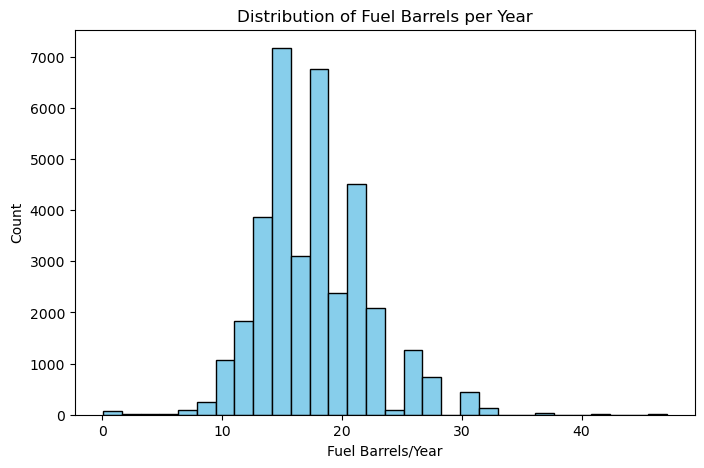

In [8]:
# your code here

# --- Plot histogram for 'Fuel Barrels/Year' ---
plt.figure(figsize=(8,5))
plt.hist(vehicles['Fuel Barrels/Year'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Fuel Barrels per Year')
plt.xlabel('Fuel Barrels/Year')
plt.ylabel('Count')
plt.show()


2. CO2 Emission Grams/Mile 

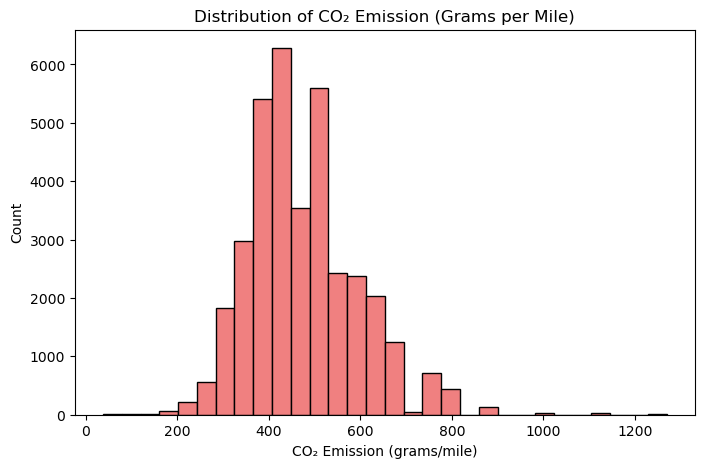

In [10]:
# your code here

#  Plot histogram for 'CO2 Emission Grams/Mile' 
plt.figure(figsize=(8,5))
plt.hist(vehicles['CO2 Emission Grams/Mile'], bins=30, color='lightcoral', edgecolor='black')
plt.title('Distribution of CO₂ Emission (Grams per Mile)')
plt.xlabel('CO₂ Emission (grams/mile)')
plt.ylabel('Count')
plt.show()


3. Combined MPG

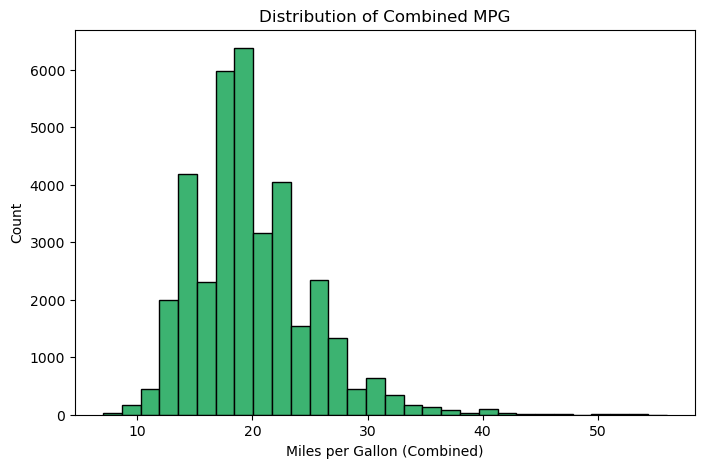

In [12]:
# your code here

# Plot histogram for 'Combined MPG' 
plt.figure(figsize=(8,5))
plt.hist(vehicles['Combined MPG'], bins=30, color='mediumseagreen', edgecolor='black')
plt.title('Distribution of Combined MPG')
plt.xlabel('Miles per Gallon (Combined)')
plt.ylabel('Count')
plt.show()


Which one(s) of the variables are nearly normally distributed? How do you know?

Fuel Barrels/Year: Right-skewed — most vehicles consume little fuel, with a few heavy consumers extending the tail. → Not normal.

CO₂ Emission (Grams/Mile): Also right-skewed — majority emit moderate CO₂, few very high emitters. → Not normal.

Combined MPG: Slightly left-skewed but roughly symmetric around the mean — closest to a bell-shaped curve. → Nearly normal, but not normal.

> Conclusion: Among the three, Combined MPG is the only variable that appears approximately normally distributed, while the others are clearly skewed.

None of them are normally ditributed. 

## Exponential Distribution

1. Using `numpy.random.exponential`, create a function that returns a list of numbers exponentially distributed with the mean of 10. 

1. Use the function to generate two number sequences with the size of 10 and 100.

1. Plot the distributions as histograms with the nubmer of bins as 100.

Your output should look like below:

![exponential distribution](ed.png)

In [ ]:
# your code here

How are the two distributions different?

The mean changes, so the distribution changes as well. 

## Exponential Distribution of Real Data

Suppose that the amount of time one spends in a bank is exponentially distributed with mean as 10 minutes (i.e. λ = 1/10). What is the probability that a customer will spend less than fifteen minutes in the bank? 

Write a code in python to solve this problem

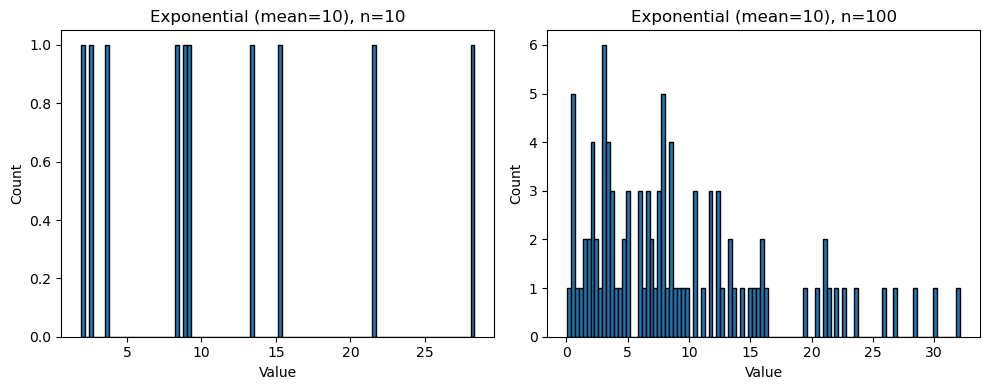

Theoretical P(X < 15) = 0.7769
Empirical  P(X < 15) with n=10  = 0.7000
Empirical  P(X < 15) with n=100 = 0.8200


In [14]:
# --- Import necessary libraries ---
import numpy as np                 # NumPy is used for numerical operations and random number generation
import matplotlib.pyplot as plt    # Matplotlib is used for plotting charts and histograms
from math import exp               # exp() lets us compute e^x (used in the exponential probability formula)


# --- Step 1: Define a function to generate exponential numbers ---
def generate_exponential_numbers(mean, size):
    """
    Generate exponentially distributed random numbers.

    Parameters:
        mean (float): The mean (average) of the exponential distribution (mean = 1/lambda)
        size (int): The number of random samples to generate

    Returns:
        np.ndarray: A NumPy array containing exponentially distributed random numbers
    """

    # In NumPy's exponential distribution:
    # 'scale' = 1/lambda = mean
    # This sets the average value of the distribution.
    numbers = np.random.exponential(scale=mean, size=size)

    # Return the array of generated numbers
    return numbers


# --- Step 2: Generate two random samples using the function ---
mean = 10                         # The mean of the exponential distribution (average waiting time)
data_10  = generate_exponential_numbers(mean=mean, size=10)    # Small sample of 10 random values
data_100 = generate_exponential_numbers(mean=mean, size=100)   # Larger sample of 100 random values


# --- Step 3: Plot histograms to visualize both samples ---
plt.figure(figsize=(10,4))        # Create a figure with width=10 inches, height=4 inches

# First histogram: small sample (n=10)
plt.subplot(1, 2, 1)              # Create the first subplot (1 row, 2 columns, position 1)
plt.hist(data_10, bins=100, edgecolor='black')  # Plot histogram with 100 bins, black edges
plt.title('Exponential (mean=10), n=10')        # Add title
plt.xlabel('Value')                            # Label x-axis
plt.ylabel('Count')                            # Label y-axis

# Second histogram: larger sample (n=100)
plt.subplot(1, 2, 2)              # Second subplot (position 2)
plt.hist(data_100, bins=100, edgecolor='black') # Same plot but smoother due to larger sample
plt.title('Exponential (mean=10), n=100')       # Title for the second plot
plt.xlabel('Value')                            # Label x-axis
plt.ylabel('Count')                            # Label y-axis

plt.tight_layout()               # Automatically adjust spacing to prevent label overlap
plt.show()                       # Display both histograms on screen


# --- Step 4: Calculate theoretical and empirical probability P(X < 15) ---

# The exponential distribution parameter lambda = 1 / mean
lam = 1 / mean                    # Compute lambda (rate of events)

# Theoretical probability using the CDF formula:
# P(X < x) = 1 - e^(-lambda * x)
p_theory = 1 - exp(-lam * 15)     # Calculate P(X < 15) theoretically

# Empirical probabilities from our samples:
# Count how many generated values are below 15, then divide by total count
p_emp_10  = (data_10  < 15).mean()   # Empirical probability for n=10
p_emp_100 = (data_100 < 15).mean()   # Empirical probability for n=100

# Print all results in a clear format
print(f"Theoretical P(X < 15) = {p_theory:.4f}")    # Expected probability from theory
print(f"Empirical  P(X < 15) with n=10  = {p_emp_10:.4f}")  # Observed proportion in small sample
print(f"Empirical  P(X < 15) with n=100 = {p_emp_100:.4f}") # Observed proportion in larger sample


What is the probability that the customer will spend more than 15 minutes

In [15]:
# your code here

from math import exp

# Given mean
mean = 10
lam = 1 / mean

# Probability that X > 15
p_greater_15 = exp(-lam * 15)

print(f"P(X > 15) = {p_greater_15:.4f}")


P(X > 15) = 0.2231
